In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/bandung_rainfall_2010_2026.csv', parse_dates=['date'], index_col='date')
y = df['precipitation_mm'].values
print(y.shape)
print(y[:5])

(5995,)
[24.2 18.3 19.6 23.8 15.5]


In [3]:
def sample_acf(y, max_lag):
    n = len(y)
    y_mean = np.mean(y)
    y_centered = y - y_mean
    
    gamma_0 = np.sum(y_centered ** 2) / n
    
    acf_values = []
    for k in range(1, max_lag + 1):
        gamma_k = np.sum(y_centered[k:] * y_centered[:n-k]) / n
        acf_values.append(gamma_k / gamma_0)
    
    return np.array(acf_values)

rho = sample_acf(y, max_lag=2)
print(f"rho(1) = {rho[0]:.4f}")
print(f"rho(2) = {rho[1]:.4f}")

rho(1) = 0.4528
rho(2) = 0.3174


In [4]:
rho1, rho2 = rho[0], rho[1]

phi1 = rho1 * (1 - rho2) / (1 - rho1**2)
phi2 = (rho2 - rho1**2) / (1 - rho1**2)

print(f"phi_1 = {phi1:.4f}")
print(f"phi_2 = {phi2:.4f}")

phi_1 = 0.3888
phi_2 = 0.1413


In [5]:
mu = np.mean(y)
c = mu * (1 - phi1 - phi2)

def ar2_predict(y, phi1, phi2, c):
    """One-step ahead predictions untuk AR(2)."""
    n = len(y)
    y_hat = np.zeros(n)
    
    # Dua observasi pertama tidak bisa diprediksi
    y_hat[0] = np.nan
    y_hat[1] = np.nan
    
    for t in range(2, n):
        y_hat[t] = c + phi1 * y[t-1] + phi2 * y[t-2]
    
    return y_hat

y_hat = ar2_predict(y, phi1, phi2, c)

print(f"c (intercept) = {c:.4f}")
print(f"Contoh prediksi t=2: {y_hat[2]:.4f}, aktual: {y[2]:.4f}")
print(f"Contoh prediksi t=3: {y_hat[3]:.4f}, aktual: {y[3]:.4f}")

c (intercept) = 3.6013
Contoh prediksi t=2: 14.1371, aktual: 19.6000
Contoh prediksi t=3: 13.8088, aktual: 23.8000


In [6]:
def walk_forward_validation(y, train_ratio=0.8):
    n = len(y)
    n_train = int(n * train_ratio)
    
    actuals = []
    predictions = []
    
    # Fit sekali pada training set penuh
    y_train = y[:n_train]
    rho_train = sample_acf(y_train, max_lag=2)
    
    phi1_wf = rho_train[0] * (1 - rho_train[1]) / (1 - rho_train[0]**2)
    phi2_wf = (rho_train[1] - rho_train[0]**2) / (1 - rho_train[0]**2)
    mu_train = np.mean(y_train)
    c_wf = mu_train * (1 - phi1_wf - phi2_wf)
    
    # Prediksi satu langkah ke depan pada test set
    for t in range(n_train, n):
        y_hat_t = c_wf + phi1_wf * y[t-1] + phi2_wf * y[t-2]
        predictions.append(y_hat_t)
        actuals.append(y[t])
    
    return np.array(actuals), np.array(predictions), phi1_wf, phi2_wf, c_wf

actuals, predictions, phi1_wf, phi2_wf, c_wf = walk_forward_validation(y)

print(f"phi_1 (train) = {phi1_wf:.4f}")
print(f"phi_2 (train) = {phi2_wf:.4f}")
print(f"Jumlah prediksi: {len(predictions)}")

phi_1 (train) = 0.3886
phi_2 (train) = 0.1470
Jumlah prediksi: 1199


In [7]:
def mae(actuals, predictions):
    return np.mean(np.abs(actuals - predictions))

def rmse(actuals, predictions):
    return np.sqrt(np.mean((actuals - predictions)**2))

print(f"MAE  = {mae(actuals, predictions):.4f} mm")
print(f"RMSE = {rmse(actuals, predictions):.4f} mm")
print(f"\nBaseline comparison:")
print(f"Mean rainfall (test set) = {np.mean(actuals):.4f} mm")
print(f"Std rainfall  (test set) = {np.std(actuals):.4f} mm")

MAE  = 5.5018 mm
RMSE = 7.7708 mm

Baseline comparison:
Mean rainfall (test set) = 5.4997 mm
Std rainfall  (test set) = 8.3111 mm


In [8]:
skill_score = 1 - (rmse(actuals, predictions) / np.std(actuals))
print(f"Skill Score = {skill_score:.4f}")

Skill Score = 0.0650


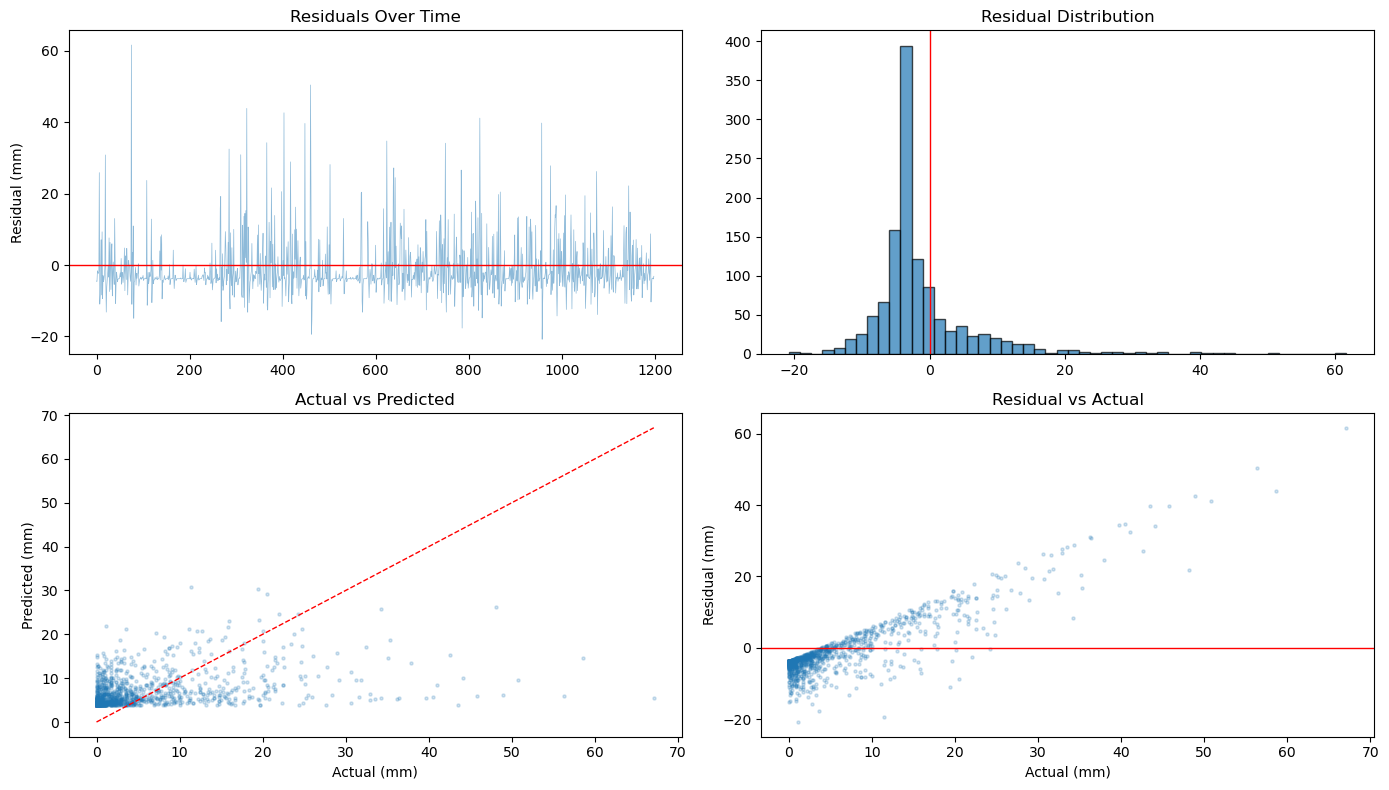

In [9]:
residuals = actuals - predictions

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Residual over time
axes[0,0].plot(residuals, alpha=0.5, linewidth=0.5)
axes[0,0].axhline(0, color='red', linewidth=1)
axes[0,0].set_title('Residuals Over Time')
axes[0,0].set_ylabel('Residual (mm)')

# 2. Residual distribution
axes[0,1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0,1].axvline(0, color='red', linewidth=1)
axes[0,1].set_title('Residual Distribution')

# 3. Actual vs Predicted
axes[1,0].scatter(actuals, predictions, alpha=0.2, s=5)
axes[1,0].plot([0, actuals.max()], [0, actuals.max()], 'r--', linewidth=1)
axes[1,0].set_xlabel('Actual (mm)')
axes[1,0].set_ylabel('Predicted (mm)')
axes[1,0].set_title('Actual vs Predicted')

# 4. Residual vs Actual (untuk deteksi bias sistematis)
axes[1,1].scatter(actuals, residuals, alpha=0.2, s=5)
axes[1,1].axhline(0, color='red', linewidth=1)
axes[1,1].set_xlabel('Actual (mm)')
axes[1,1].set_ylabel('Residual (mm)')
axes[1,1].set_title('Residual vs Actual')

plt.tight_layout()
plt.savefig('../outputs/ar2_residuals.png', dpi=150)
plt.show()

In [10]:
from statsmodels.tsa.ar_model import AutoReg

model_sm = AutoReg(y, lags=2, trend='c').fit()
print(f"statsmodels phi_1 = {model_sm.params[1]:.4f}")
print(f"statsmodels phi_2 = {model_sm.params[2]:.4f}")
print(f"statsmodels c     = {model_sm.params[0]:.4f}")
print()
print(f"Yule-Walker phi_1 = {phi1_wf:.4f}")
print(f"Yule-Walker phi_2 = {phi2_wf:.4f}")
print(f"Yule-Walker c     = {c_wf:.4f}")

statsmodels phi_1 = 0.3887
statsmodels phi_2 = 0.1414
statsmodels c     = 3.5971

Yule-Walker phi_1 = 0.3886
Yule-Walker phi_2 = 0.1470
Yule-Walker c     = 3.8109


In [11]:
from scipy.optimize import minimize

def neg_log_likelihood(params, y):
    c, phi1, phi2 = params
    n = len(y)
    
    residuals = np.array([
        y[t] - c - phi1 * y[t-1] - phi2 * y[t-2]
        for t in range(2, n)
    ])
    
    sigma2 = np.var(residuals)
    
    if sigma2 <= 0:
        return 1e10
    
    nll = (n-2)/2 * np.log(2 * np.pi * sigma2) + np.sum(residuals**2) / (2 * sigma2)
    return nll

y_train = y[:int(len(y) * 0.8)]
params0 = [np.mean(y_train), 0.3, 0.1]

result = minimize(neg_log_likelihood, params0, args=(y_train,), method='Nelder-Mead')

c_mle, phi1_mle, phi2_mle = result.x
print(f"MLE phi_1 = {phi1_mle:.4f}")
print(f"MLE phi_2 = {phi2_mle:.4f}")
print(f"MLE c     = {c_mle:.4f}")
print()
print(f"Yule-Walker phi_1 = {phi1_wf:.4f}")
print(f"Yule-Walker phi_2 = {phi2_wf:.4f}")

MLE phi_1 = 0.3885
MLE phi_2 = 0.1471
MLE c     = 3.8067

Yule-Walker phi_1 = 0.3886
Yule-Walker phi_2 = 0.1470


In [12]:
def difference(y, d):
    """Differencing orde-d dari scratch."""
    y_diff = y.copy()
    for _ in range(d):
        y_diff = np.diff(y_diff)
    return y_diff

def inverse_difference(y_orig, y_diff_pred, d):
    """Kembalikan prediksi ke skala asli."""
    result = y_diff_pred.copy()
    for _ in range(d):
        result = np.cumsum(np.append(y_orig[d-1], result))
    return result

# Verifikasi pada data kita
y_d0 = difference(y, d=0)
y_d1 = difference(y, d=1)
y_d2 = difference(y, d=2)

print(f"d=0: panjang {len(y_d0)}, mean={y_d0.mean():.4f}, std={y_d0.std():.4f}")
print(f"d=1: panjang {len(y_d1)}, mean={y_d1.mean():.4f}, std={y_d1.std():.4f}")
print(f"d=2: panjang {len(y_d2)}, mean={y_d2.mean():.4f}, std={y_d2.std():.4f}")

d=0: panjang 5995, mean=7.6650, std=10.2605
d=1: panjang 5994, mean=-0.0039, std=10.7319
d=2: panjang 5993, mean=0.0011, std=17.8064


In [13]:
def ma_log_likelihood(params, y, q):
    mu = params[0]
    thetas = params[1:q+1]
    
    n = len(y)
    errors = np.zeros(n)
    
    for t in range(n):
        pred = mu
        for j in range(q):
            if t - j - 1 >= 0:
                pred += thetas[j] * errors[t-j-1]
        errors[t] = y[t] - pred
    
    sigma2 = np.var(errors)
    if sigma2 <= 0:
        return 1e10
    
    nll = n/2 * np.log(2 * np.pi * sigma2) + np.sum(errors**2) / (2 * sigma2)
    return nll

# Fit MA(1) pada training set
y_train = y[:int(len(y) * 0.8)]
params0_ma = [np.mean(y_train), 0.3]

result_ma = minimize(ma_log_likelihood, params0_ma, 
                     args=(y_train, 1), method='Nelder-Mead')

mu_ma, theta1_ma = result_ma.x
print(f"MA(1) mu     = {mu_ma:.4f}")
print(f"MA(1) theta1 = {theta1_ma:.4f}")
print(f"Converged: {result_ma.success}")

MA(1) mu     = 8.2076
MA(1) theta1 = 0.3504
Converged: True


In [14]:
def arma_log_likelihood(params, y, p, q):
    c = params[0]
    phis = params[1:p+1]
    thetas = params[p+1:p+q+1]
    
    n = len(y)
    errors = np.zeros(n)
    
    for t in range(n):
        pred = c
        for i in range(p):
            if t - i - 1 >= 0:
                pred += phis[i] * y[t-i-1]
        for j in range(q):
            if t - j - 1 >= 0:
                pred += thetas[j] * errors[t-j-1]
        errors[t] = y[t] - pred
    
    sigma2 = np.var(errors)
    if sigma2 <= 0:
        return 1e10
    
    nll = n/2 * np.log(2 * np.pi * sigma2) + np.sum(errors**2) / (2 * sigma2)
    return nll

# Initial guess dari estimasi terpisah yang sudah kita punya
params0_arma = [np.mean(y_train), phi1_wf, phi2_wf, theta1_ma]

result_arma = minimize(arma_log_likelihood, params0_arma,
                       args=(y_train, 2, 1), method='Nelder-Mead',
                       options={'maxiter': 10000})

c_arma = result_arma.x[0]
phi1_arma, phi2_arma = result_arma.x[1], result_arma.x[2]
theta1_arma = result_arma.x[3]

print(f"ARMA(2,1) c      = {c_arma:.4f}")
print(f"ARMA(2,1) phi_1  = {phi1_arma:.4f}")
print(f"ARMA(2,1) phi_2  = {phi2_arma:.4f}")
print(f"ARMA(2,1) theta1 = {theta1_arma:.4f}")
print(f"Converged: {result_arma.success}")

ARMA(2,1) c      = 0.1059
ARMA(2,1) phi_1  = 1.2334
ARMA(2,1) phi_2  = -0.2463
ARMA(2,1) theta1 = -0.9117
Converged: True


In [15]:
phi1_a, phi2_a = phi1_arma, phi2_arma

cond1 = abs(phi2_a) < 1
cond2 = phi1_a + phi2_a < 1
cond3 = phi2_a - phi1_a < 1

print(f"|phi2| < 1:          {cond1} ({abs(phi2_a):.4f})")
print(f"phi1 + phi2 < 1:     {cond2} ({phi1_a + phi2_a:.4f})")
print(f"phi2 - phi1 < 1:     {cond3} ({phi2_a - phi1_a:.4f})")
print(f"|theta1| < 1 (MA invertibility): {abs(theta1_arma) < 1} ({abs(theta1_arma):.4f})")

|phi2| < 1:          True (0.2463)
phi1 + phi2 < 1:     True (0.9871)
phi2 - phi1 < 1:     True (-1.4797)
|theta1| < 1 (MA invertibility): True (0.9117)


In [16]:
n_train = len(y_train)

# Log-likelihood masing-masing model
ll_ar2   = -neg_log_likelihood([c_wf, phi1_wf, phi2_wf], y_train)
ll_arma  = -arma_log_likelihood(result_arma.x, y_train, 2, 1)

# Jumlah parameter: c, phi1, phi2, (theta1), sigma2
k_ar2  = 4
k_arma = 5

aic_ar2  = 2*k_ar2  - 2*ll_ar2
aic_arma = 2*k_arma - 2*ll_arma

bic_ar2  = k_ar2  * np.log(n_train) - 2*ll_ar2
bic_arma = k_arma * np.log(n_train) - 2*ll_arma

print(f"{'':15} {'AR(2)':>10} {'ARMA(2,1)':>10}")
print(f"{'Log-likelihood':15} {ll_ar2:>10.2f} {ll_arma:>10.2f}")
print(f"{'AIC':15} {aic_ar2:>10.2f} {aic_arma:>10.2f}")
print(f"{'BIC':15} {bic_ar2:>10.2f} {bic_arma:>10.2f}")

                     AR(2)  ARMA(2,1)
Log-likelihood   -17520.46  -17385.16
AIC               35048.92   34780.32
BIC               35074.82   34812.70


In [19]:
class ARIMA:
    def __init__(self, p, d, q):
        self.p = p
        self.d = d
        self.q = q
        self.params_ = None
        
    def fit(self, y):
        y_diff = difference(y, self.d)
        
        p, q = self.p, self.q
        params0 = np.zeros(1 + p + q)
        params0[0] = np.mean(y_diff)
        if p > 0: params0[1] = 0.3
        if q > 0: params0[1+p] = 0.3
        
        result = minimize(arma_log_likelihood, params0,
                         args=(y_diff, p, q), method='Nelder-Mead',
                         options={'maxiter': 10000})
        self.params_ = result.x
        return self
    
    def _predict_one_diff(self, y_window, error_window):
        p, q = self.p, self.q
        c      = self.params_[0]
        phis   = self.params_[1:p+1]
        thetas = self.params_[p+1:p+q+1]
        
        pred = c
        for i in range(p):
            if len(y_window) > i:
                pred += phis[i] * y_window[-(i+1)]
        for j in range(q):
            if len(error_window) > j:
                pred += thetas[j] * error_window[-(j+1)]
        return pred
    
    def walk_forward(self, y, train_ratio=0.8):
        n       = len(y)
        n_train = int(n * train_ratio)
        
        self.fit(y[:n_train])
        
        y_diff = difference(y, self.d)
        
        # Hitung error in-sample untuk inisialisasi
        errors = np.zeros(len(y_diff))
        for t in range(len(y_diff)):
            y_win = y_diff[max(0,t-self.p):t]
            e_win = errors[max(0,t-self.q):t]
            pred  = self._predict_one_diff(y_win, e_win)
            errors[t] = y_diff[t] - pred
        
        # Walk-forward pada test set
        actuals     = []
        predictions = []
        
        n_train_diff = n_train - self.d
        
        for t in range(n_train_diff, len(y_diff)):
            y_win = y_diff[max(0,t-self.p):t]
            e_win = errors[max(0,t-self.q):t]
            
            pred_diff = self._predict_one_diff(y_win, e_win)
            
            # Inverse differencing ke skala asli
            if self.d == 0:
                pred_orig = pred_diff
            else:
                pred_orig = y[t + self.d - 1] + pred_diff
            
            actuals.append(y[t + self.d])
            predictions.append(pred_orig)
            
            errors[t] = y_diff[t] - pred_diff
        
        return np.array(actuals), np.array(predictions)

In [21]:
naive_pred = np.full(len(act_ar2), np.mean(y[:int(len(y)*0.8)]))

print(f"{'Model':15} {'MAE':>8} {'RMSE':>8} {'Skill':>8}")
print("-" * 43)

for name, act, pred in [
    ("Naive",     act_ar2,    naive_pred),
    ("AR(2)",     act_ar2,    pred_ar2),
    ("ARMA(2,1)", act_arma21, pred_arma21),
]:
    m  = mae(act, pred)
    r  = rmse(act, pred)
    ss = 1 - r / np.std(act)
    print(f"{name:15} {m:>8.4f} {r:>8.4f} {ss:>8.4f}")

Model                MAE     RMSE    Skill
-------------------------------------------
Naive             7.0541   8.7407  -0.0517
AR(2)             5.5030   7.7708   0.0650
ARMA(2,1)         5.0794   7.6544   0.0790
